<a href="https://colab.research.google.com/github/xMrTuffnut/ai-companion-wellbeing/blob/main/notebooks/02_rq1_companion_vs_others.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RQ1: Does well-being differ between companion users and other users?
**Owner: Person B**

Rules: only the owner edits this notebook. Before saving to GitHub: *Runtime → Restart and run all*.

In [1]:
# ---- Shared setup cell: same in every notebook, don't change it alone ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")

# Raw data (original study). Once data/clean.csv exists, switch to CLEAN_URL.
RAW_URL = "https://raw.githubusercontent.com/SALT-NLP/AI-companionship-well-being/main/data.csv"
CLEAN_URL = "https://raw.githubusercontent.com/xMrTuffnut/ai-companion-wellbeing/main/data/clean.csv"

df = pd.read_csv(CLEAN_URL)
print(df.shape)

(1131, 17)


In [2]:
# Save a figure and download it (then upload it to figures/ on GitHub)
def save_fig(name):
    plt.savefig(name, dpi=200, bbox_inches="tight")
    try:
        from google.colab import files
        files.download(name)
    except ImportError:
        pass  # not in Colab: file is saved next to the notebook

**Step 1: Descriptive statistics.** We compare well-being between participants who mainly use the chatbot as a companion and all other participants.

In [3]:
df.groupby("companion_group")["well_being"].agg(["count", "mean", "std", "median"]).round(2)

,count,mean,std,median
companion_group,,,,
Companion (primary use),134,4.44,1.45,4.67
Other use,997,4.84,1.31,5.00


**Step 2: Welch t-test.** We use Welch's t-test because the groups have very different sizes (134 vs. 997) and different spreads. Cohen's d shows how large the difference is.

In [4]:
companion = df.loc[df["companionship_prim"] == 1, "well_being"]
others = df.loc[df["companionship_prim"] == 0, "well_being"]

result = stats.ttest_ind(companion, others, equal_var=False)
print(f"Difference in means: {companion.mean() - others.mean():.2f} points")
print(f"t = {result.statistic:.2f}, p = {result.pvalue:.4f}")

pooled_sd = np.sqrt((companion.var() + others.var()) / 2)
d = (companion.mean() - others.mean()) / pooled_sd
print(f"Cohen's d = {d:.2f}")

Difference in means: -0.40 points
t = -3.01, p = 0.0030
Cohen's d = -0.29


**Step 3: Boxplot.** The boxplot shows the distribution of well-being in both groups.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

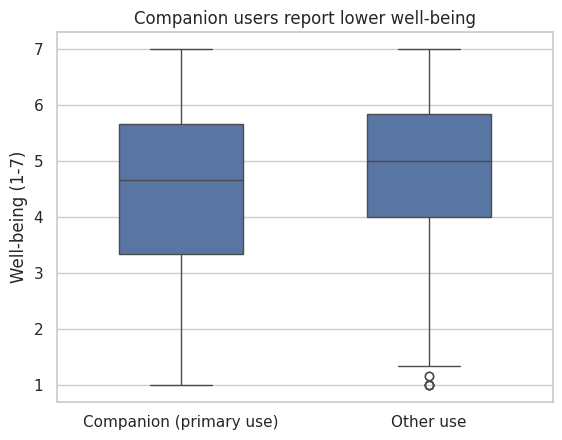

In [5]:
order = ["Companion (primary use)", "Other use"]
sns.boxplot(data=df, x="companion_group", y="well_being", order=order, width=0.5)
plt.xlabel("")
plt.ylabel("Well-being (1-7)")
plt.title("Companion users report lower well-being")
save_fig("rq1_boxplot.png")
plt.show()

**Step 4: Robustness check.** We repeat the test with the second companionship measure, an AI classification of how participants describe their chatbot relationship (companionship_desc).

In [6]:
desc_yes = df.loc[df["companionship_desc"] == 1, "well_being"]
desc_no = df.loc[df["companionship_desc"] == 0, "well_being"]
r2 = stats.ttest_ind(desc_yes, desc_no, equal_var=False)
print(f"n = {len(desc_yes)} vs {len(desc_no)}, means {desc_yes.mean():.2f} vs {desc_no.mean():.2f}")
print(f"t = {r2.statistic:.2f}, p = {r2.pvalue:.4f}")

n = 577 vs 554, means 4.70 vs 4.89
t = -2.44, p = 0.0150


**Interpretation.** Participants who mainly use the chatbot as a companion report lower well-being (M = 4.44, SD = 1.45, n = 134) than other users (M = 4.84, SD = 1.31, n = 997). The difference of 0.40 points on the 1–7 scale is statistically significant (Welch's t = −3.01, p = 0.003) but small (Cohen's d = −0.29). The same pattern appears with the AI-classified companionship measure (4.70 vs. 4.89, p = 0.015). Because this is a one-time survey, we cannot tell whether companion use lowers well-being or whether people with lower well-being are more likely to turn to AI companions.